In [1]:
# !pip install split-folders

In [39]:
import io
import os
import random
import requests
import shutil
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import DataLoader, random_split
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
import splitfolders

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')

In [3]:
input_folder = './data/'
output_folder = './dataset/'
classes = os.listdir(input_folder)

random.seed(42)

for cls in classes:
    imgs = [os.path.join(input_folder, cls, f) for f in os.listdir(os.path.join(input_folder, cls))]
    random.shuffle(imgs)

    train, temp = train_test_split(imgs, test_size=0.3, random_state=42)
    val, test = train_test_split(temp, test_size=0.15, random_state=42)

    for subset, items in zip(['train', 'val', 'test'], [train, val, test]):
        for path in items:
            dest = os.path.join(output_folder, subset, cls)
            os.makedirs(dest, exist_ok=True)
            shutil.copy(path, dest)

In [4]:
image_size = (224, 244)
batch_size = 16
epochs = 15
learning_rate = 1e-4

device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device is {device}')

Using device is cuda


In [5]:
train_transforms = transforms.Compose([
    transforms.Resize(image_size),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(image_size, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

train_dataset = ImageFolder('./dataset/train/', transform=train_transforms)
test_dataset = ImageFolder('./dataset/test/', transform=test_transforms)
val_dataset = ImageFolder('./dataset/val/', transform=val_transforms)

In [6]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [7]:
images, labels = next(iter(test_loader))
print(f'Images shape: {images.shape}')
print(f'Labels shape: {labels.shape}')

Images shape: torch.Size([16, 3, 224, 244])
Labels shape: torch.Size([16])


In [8]:
def im_convert(tensor):
    if tensor.dim() == 4:
        tensor = tensor.squeeze(0)
        
    image = tensor.clone().cpu().detach().numpy()
    image = image.transpose(1, 2, 0)
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = image * std + mean

    image = image.clip(0, 1)
    return image

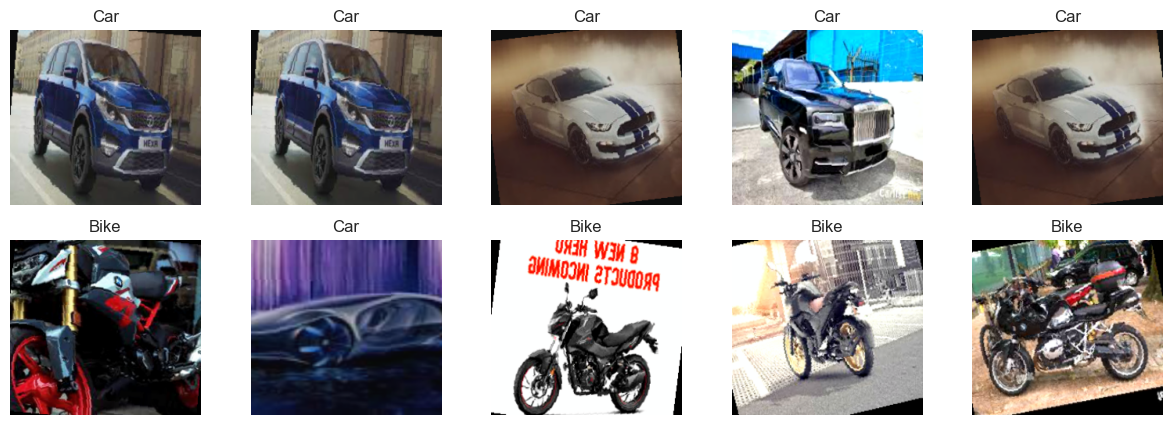

In [9]:
images, labels = next(iter(train_loader))

ax = plt.figure(figsize=(15, 5))
for i in range(10):
    ax.add_subplot(2, 5, i+1, xticks=[], yticks=[])
    idx = np.random.randint(0, len(images))
    plt.imshow(im_convert(images[idx]))
    plt.title('Bike' if labels[idx] == 0 else 'Car')

In [10]:
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT).to(device)
# model

In [11]:
for param in model.parameters():
    param.requires_grad = False

for param in model.features[-3:].parameters():
    param.requires_grad = True

In [12]:
for name, param in model.named_parameters():
    print(name, param.requires_grad)
    break

features.0.0.weight False


In [13]:
in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 2),
).to(device)

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)

In [15]:
# Training Loop

train_loss_history = []
val_loss_history = []

train_accuracy_history = []
val_accuracy_history = []

patience = 4
early_stop_counter = 0
best_val_loss = float('inf')

for epoch in range(epochs):

    train_running_loss = 0.0
    train_running_corrects = 0

    model.train() # Training the model
    for ii, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        train_running_loss += loss.item()

        _, preds = torch.max(outputs, dim=1)
        train_running_corrects += (preds == labels).sum().item()

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    val_running_loss = 0.0
    val_running_corrects = 0
    
    model.eval()
    with torch.no_grad():
        for ii, (inputs, labels) in enumerate(val_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

            _, preds = torch.max(outputs, dim=1)
            val_running_corrects += (preds == labels).sum().item()
    
    train_avg_loss = train_running_loss / len(train_loader)
    val_avg_loss = val_running_loss / len(val_loader)
    
    train_avg_acc = train_running_corrects / len(train_dataset)
    val_avg_acc = val_running_corrects / len(val_dataset)
    
    train_loss_history.append(train_avg_loss)
    val_loss_history.append(val_avg_loss)
    
    train_accuracy_history.append(train_avg_acc)
    val_accuracy_history.append(val_avg_acc)

    # Checkpoints and saving the best model 
    if best_val_loss > val_avg_loss:
        best_val_loss = val_avg_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), './models/best_model.pth')
        print('Validation loss improved! Saving the best model.')
    else:
        if early_stop_counter >= patience:
            print(f"Early stopping triggered after {patience} epochs with no improvement.")
            break
        

    # Updating learning rate
    scheduler.step(val_avg_loss)
    
    print(f'\nEpoch {epoch + 1}/{epochs}')
    print(f'Training loss: {train_avg_loss:.4f}\t Training accuracy {train_avg_acc * 100:.4f}%')
    print(f'Validation loss: {val_avg_loss:.4f}\t Validation accuracy {val_avg_acc * 100:.4f}%')
    print('-' * 70)

Validation loss improved! Saving the best model.

Epoch 1/15
Training loss: 0.1813	 Training accuracy 93.6786%
Validation loss: 0.0339	 Validation accuracy 99.2157%
----------------------------------------------------------------------
Validation loss improved! Saving the best model.

Epoch 2/15
Training loss: 0.0566	 Training accuracy 97.8571%
Validation loss: 0.0246	 Validation accuracy 99.2157%
----------------------------------------------------------------------

Epoch 3/15
Training loss: 0.0463	 Training accuracy 98.4286%
Validation loss: 0.0269	 Validation accuracy 99.3137%
----------------------------------------------------------------------
Validation loss improved! Saving the best model.

Epoch 4/15
Training loss: 0.0428	 Training accuracy 98.5000%
Validation loss: 0.0242	 Validation accuracy 99.3137%
----------------------------------------------------------------------
Validation loss improved! Saving the best model.

Epoch 5/15
Training loss: 0.0351	 Training accuracy 98.

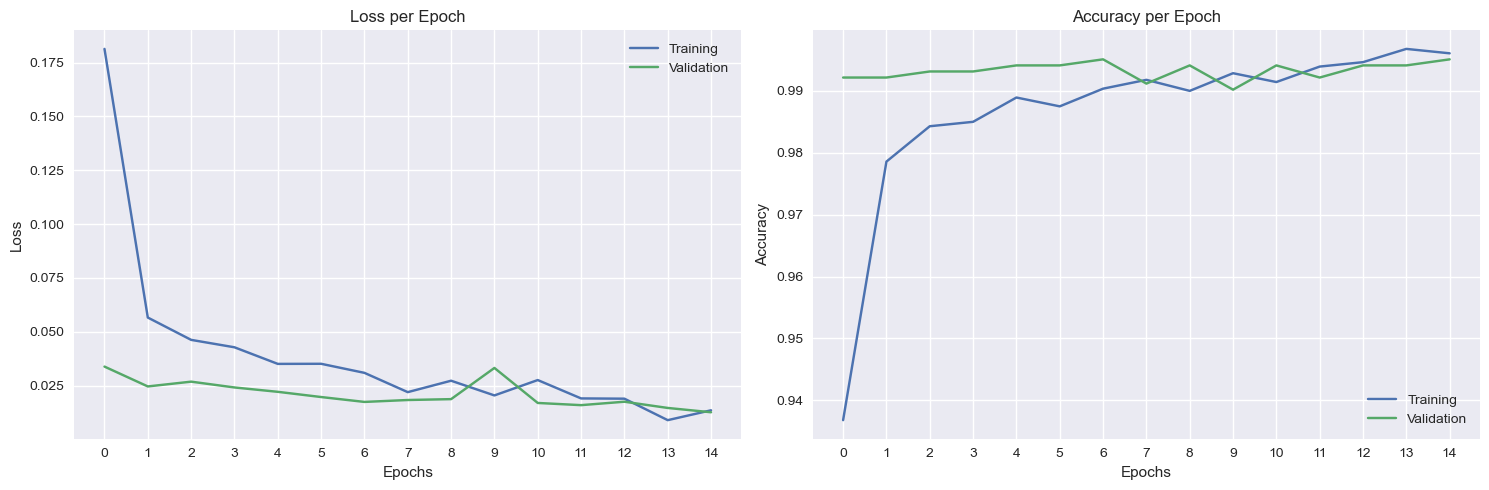

In [16]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Training')
plt.plot(val_loss_history, label='Validation')
plt.title('Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(range(epochs))
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracy_history, label='Training')
plt.plot(val_accuracy_history, label='Validation')
plt.title('Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(range(epochs))
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
# Predicting model on test dataset

model.load_state_dict(torch.load('./models/best_model.pth'))
model.eval()

test_running_loss = 0.0
test_running_corrects = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_running_loss += loss.item()

        _, preds = torch.max(outputs, dim=1)
        test_running_corrects += (preds == labels).sum().item()

    test_avg_loss = test_running_loss / len(test_loader)
    test_avg_acc = test_running_corrects / len(test_dataset)

print('--- Result of test dataset ---')
print(f'Final Test Loss: {test_avg_loss:.4f}')
print(f'Final Test Accuracy: {test_avg_acc * 100:.2f}%')
print('-------------------------')

--- Result of test dataset ---
Final Test Loss: 0.0108
Final Test Accuracy: 99.44%
-------------------------


In [40]:
def download_image(url):
    response = requests.get(url, timeout=10)
    if response.status_code != 200:
        raise Exception("Failed to download image")

    img = Image.open(io.BytesIO(response.content)).convert("RGB")
    return img


In [41]:
def predict(model, img, device):
    model.eval()
    
    tensor = test_transforms(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(tensor)
        _, pred = torch.max(outputs, dim=1)

    return pred.item()


In [42]:
url = "https://www.saadatrent.com/mag/wp-content/uploads/2024/04/The-best-Iranian-car-of-the-year.webp"

img = download_image(url)
prediction = predict(model, img, device)

class_names = ["bike", "car"]
print("Prediction:", class_names[prediction])


Prediction: car
